# 1. LSTM

## data leakage 수정본
- train_test_split을 영화 단위로

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [4]:
!pip install torch torchvision scikit-learn -q

In [16]:
import numpy as np
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

## 1. train 및 val .npy 데이터 로드 & 합치기

In [13]:
# 1. 데이터 로드
TRAIN_PATH = '/content/drive/MyDrive/ColabNotebooks/dataEng/DE_PJ2/npyForLSTM/trainandval'

X_all, y_all, movie_all = [], [], []
for x_path in sorted(Path(TRAIN_PATH).glob('*_X.npy')):
    name = x_path.stem.replace('_X', '')
    y_path = x_path.parent / f'{name}_y.npy'
    m_path = x_path.parent / f'{name}_movie_ids.npy'
    X_all.append(np.load(x_path))
    y_all.append(np.load(y_path))
    movie_all.append(np.load(m_path))

X = np.concatenate(X_all).astype(np.float32)
y_str = np.concatenate(y_all)
movie_ids = np.concatenate(movie_all)

LABEL_MAP = {'neg_easy': 0, 'violence': 1}
y = np.array([LABEL_MAP[l] for l in y_str], dtype=np.int64)

print(f'총 클립: {len(X)}개 | violence: {sum(y==1)}개 | neg_easy: {sum(y==0)}개')

총 클립: 33718개 | violence: 14389개 | neg_easy: 19329개


In [14]:
# 2. 영화별 정규화
X_norm = X.copy()
for movie in set(movie_ids):
    idx = np.where(movie_ids == movie)[0]
    if len(idx) > 1:
        orig_shape = X[idx].shape
        flat = X[idx].reshape(len(idx), -1)
        flat = StandardScaler().fit_transform(flat)
        X_norm[idx] = flat.reshape(orig_shape)
print('정규화 완료')

정규화 완료


## 2. train / val split
- train: 27112개 (49개 영화)
- val: 6606개 (13개 영화)

In [19]:
# 3. 영화 단위 train/val split
unique_movies = list(set(movie_ids))
np.random.seed(42)
np.random.shuffle(unique_movies)
n = len(unique_movies)
train_movies = unique_movies[:int(n*0.8)]
val_movies = unique_movies[int(n*0.8):]

train_idx = np.where(np.isin(movie_ids, train_movies))[0]
val_idx = np.where(np.isin(movie_ids, val_movies))[0]

X_train, y_train = X_norm[train_idx], y[train_idx]
X_val, y_val = X_norm[val_idx], y[val_idx]

print(f'train: {len(X_train)}개 ({len(train_movies)}개 영화)')
print(f'val: {len(X_val)}개 ({len(val_movies)}개 영화)')

train: 27112개 (49개 영화)
val: 6606개 (13개 영화)


## 4. LSTM 학습

In [20]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'디바이스: {device}')

디바이스: cuda


In [21]:
class ClipDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X)
        self.y = torch.tensor(y)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

train_loader = DataLoader(ClipDataset(X_train, y_train), batch_size=64, shuffle=True)
val_loader   = DataLoader(ClipDataset(X_val, y_val), batch_size=64)

class ViolenceLSTM(nn.Module):
    def __init__(self, input_size=2048, hidden_size=256, num_layers=2, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size, 2)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

model = ViolenceLSTM().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [22]:
EPOCHS = 30
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        pred = model(X_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            preds = model(X_batch).argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y_batch.numpy())

    acc = sum(p==l for p,l in zip(all_preds, all_labels)) / len(all_labels)
    print(f'Epoch {epoch+1}/{EPOCHS} | Loss: {total_loss/len(train_loader):.4f} | Val Acc: {acc:.4f}')


Epoch 1/30 | Loss: 0.4275 | Val Acc: 0.7286
Epoch 2/30 | Loss: 0.2478 | Val Acc: 0.7186
Epoch 3/30 | Loss: 0.1595 | Val Acc: 0.7122
Epoch 4/30 | Loss: 0.1164 | Val Acc: 0.7166
Epoch 5/30 | Loss: 0.0950 | Val Acc: 0.7183
Epoch 6/30 | Loss: 0.0770 | Val Acc: 0.7299
Epoch 7/30 | Loss: 0.0651 | Val Acc: 0.7277
Epoch 8/30 | Loss: 0.0575 | Val Acc: 0.7210
Epoch 9/30 | Loss: 0.0580 | Val Acc: 0.7228
Epoch 10/30 | Loss: 0.0522 | Val Acc: 0.7286
Epoch 11/30 | Loss: 0.0501 | Val Acc: 0.7248
Epoch 12/30 | Loss: 0.0461 | Val Acc: 0.7305
Epoch 13/30 | Loss: 0.0445 | Val Acc: 0.7243
Epoch 14/30 | Loss: 0.0426 | Val Acc: 0.7228
Epoch 15/30 | Loss: 0.0401 | Val Acc: 0.7243
Epoch 16/30 | Loss: 0.0379 | Val Acc: 0.7313
Epoch 17/30 | Loss: 0.0368 | Val Acc: 0.7289
Epoch 18/30 | Loss: 0.0349 | Val Acc: 0.7168
Epoch 19/30 | Loss: 0.0383 | Val Acc: 0.7130
Epoch 20/30 | Loss: 0.0314 | Val Acc: 0.7222
Epoch 21/30 | Loss: 0.0313 | Val Acc: 0.7228
Epoch 22/30 | Loss: 0.0301 | Val Acc: 0.7184
Epoch 23/30 | Loss:

In [23]:
print('\n--- Val classification report ---')
print(classification_report(all_labels, all_preds, target_names=['neg_easy', 'violence']))

torch.save(model.state_dict(), '/content/drive/MyDrive/ColabNotebooks/dataEng/DE_PJ2/violence_lstm_full.pth')
print('모델 저장 완료')


--- Val classification report ---
              precision    recall  f1-score   support

    neg_easy       0.76      0.81      0.78      3926
    violence       0.69      0.62      0.65      2680

    accuracy                           0.73      6606
   macro avg       0.72      0.71      0.72      6606
weighted avg       0.73      0.73      0.73      6606

모델 저장 완료


## 5. violence acc 낮음 이슈로 class_weight 주기

In [25]:
from sklearn.utils.class_weight import compute_class_weight

# class weight 계산
weights = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train)
class_weights = torch.tensor(weights, dtype=torch.float32).to(device)
print(f'neg_easy weight: {weights[0]:.3f}, violence weight: {weights[1]:.3f}')

# 모델 새로 초기화
model = ViolenceLSTM().to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

EPOCHS = 30
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        pred = model(X_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            preds = model(X_batch).argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y_batch.numpy())

    acc = sum(p==l for p,l in zip(all_preds, all_labels)) / len(all_labels)
    print(f'Epoch {epoch+1}/{EPOCHS} | Loss: {total_loss/len(train_loader):.4f} | Val Acc: {acc:.4f}')

print('\n--- Val classification report ---')
print(classification_report(all_labels, all_preds, target_names=['neg_easy', 'violence']))

torch.save(model.state_dict(), '/content/drive/MyDrive/ColabNotebooks/dataEng/DE_PJ2/violence_lstm_weighted.pth')
print('모델 저장 완료')

neg_easy weight: 0.880, violence weight: 1.158
Epoch 1/30 | Loss: 0.4253 | Val Acc: 0.7092
Epoch 2/30 | Loss: 0.2451 | Val Acc: 0.7275
Epoch 3/30 | Loss: 0.1575 | Val Acc: 0.7184
Epoch 4/30 | Loss: 0.1162 | Val Acc: 0.7171
Epoch 5/30 | Loss: 0.0971 | Val Acc: 0.7110
Epoch 6/30 | Loss: 0.0786 | Val Acc: 0.7190
Epoch 7/30 | Loss: 0.0695 | Val Acc: 0.7192
Epoch 8/30 | Loss: 0.0575 | Val Acc: 0.7148
Epoch 9/30 | Loss: 0.0584 | Val Acc: 0.7151
Epoch 10/30 | Loss: 0.0528 | Val Acc: 0.7254
Epoch 11/30 | Loss: 0.0495 | Val Acc: 0.7122
Epoch 12/30 | Loss: 0.0500 | Val Acc: 0.7145
Epoch 13/30 | Loss: 0.0422 | Val Acc: 0.7277
Epoch 14/30 | Loss: 0.0420 | Val Acc: 0.7181
Epoch 15/30 | Loss: 0.0427 | Val Acc: 0.7139
Epoch 16/30 | Loss: 0.0421 | Val Acc: 0.7165
Epoch 17/30 | Loss: 0.0356 | Val Acc: 0.7145
Epoch 18/30 | Loss: 0.0331 | Val Acc: 0.7169
Epoch 19/30 | Loss: 0.0400 | Val Acc: 0.7059
Epoch 20/30 | Loss: 0.0373 | Val Acc: 0.7206
Epoch 21/30 | Loss: 0.0322 | Val Acc: 0.7087
Epoch 22/30 | Los

## 6. Test

In [26]:
# test 데이터 로드 + 정규화
TEST_PATH = '/content/drive/MyDrive/ColabNotebooks/dataEng/DE_PJ2/npyForLSTM/test'

X_test_all, y_test_all, movie_test_all = [], [], []
for x_path in sorted(Path(TEST_PATH).glob('*_X.npy')):
    name = x_path.stem.replace('_X', '')
    y_path = x_path.parent / f'{name}_y.npy'
    m_path = x_path.parent / f'{name}_movie_ids.npy'
    X_test_all.append(np.load(x_path))
    y_test_all.append(np.load(y_path))
    movie_test_all.append(np.load(m_path))

X_test = np.concatenate(X_test_all).astype(np.float32)
y_test_str = np.concatenate(y_test_all)
movie_test_ids = np.concatenate(movie_test_all)

y_test = np.array([LABEL_MAP[str(l)] for l in y_test_str], dtype=np.int64)

In [27]:
# 영화별 정규화
X_test_norm = X_test.copy()
for movie in set(movie_test_ids):
    idx = np.where(movie_test_ids == movie)[0]
    if len(idx) > 1:
        orig_shape = X_test[idx].shape
        flat = X_test[idx].reshape(len(idx), -1)
        flat = StandardScaler().fit_transform(flat)
        X_test_norm[idx] = flat.reshape(orig_shape)

print('test 정규화 완료')

test 정규화 완료


In [28]:
# 테스트
model.eval()
X_tensor = torch.tensor(X_test_norm).to(device)
with torch.no_grad():
    preds = model(X_tensor).argmax(1).cpu().numpy()

print('\n--- Test classification report ---')
print(classification_report(y_test, preds, target_names=['neg_easy', 'violence']))


--- Test classification report ---
              precision    recall  f1-score   support

    neg_easy       0.74      0.79      0.77      3116
    violence       0.65      0.59      0.62      2079

    accuracy                           0.71      5195
   macro avg       0.70      0.69      0.69      5195
weighted avg       0.71      0.71      0.71      5195



# 2. TCN

In [29]:
!pip install pytorch-tcn -q

## 1. 모델 로드

In [30]:
from pytorch_tcn import TCN

class ViolenceTCN(nn.Module):
    def __init__(self, input_size=2048, num_channels=[128, 128, 256], dropout=0.3):
        super().__init__()
        self.tcn = TCN(
            num_inputs=input_size,
            num_channels=num_channels,
            kernel_size=2,
            dropout=dropout,
            input_shape='NLC'
        )
        self.fc = nn.Linear(num_channels[-1], 2)

    def forward(self, x):
        out = self.tcn(x)
        return self.fc(out[:, -1, :])

model_tcn = ViolenceTCN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_tcn.parameters(), lr=1e-3)

In [31]:
EPOCHS = 30
for epoch in range(EPOCHS):
    model_tcn.train()
    total_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        pred = model_tcn(X_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    model_tcn.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            preds = model_tcn(X_batch).argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y_batch.numpy())

    acc = sum(p==l for p,l in zip(all_preds, all_labels)) / len(all_labels)
    print(f'Epoch {epoch+1}/{EPOCHS} | Loss: {total_loss/len(train_loader):.4f} | Val Acc: {acc:.4f}')


Epoch 1/30 | Loss: 0.5210 | Val Acc: 0.7004
Epoch 2/30 | Loss: 0.3862 | Val Acc: 0.7210
Epoch 3/30 | Loss: 0.3024 | Val Acc: 0.6994
Epoch 4/30 | Loss: 0.2320 | Val Acc: 0.7075
Epoch 5/30 | Loss: 0.1783 | Val Acc: 0.7021
Epoch 6/30 | Loss: 0.1332 | Val Acc: 0.7118
Epoch 7/30 | Loss: 0.1093 | Val Acc: 0.7095
Epoch 8/30 | Loss: 0.0980 | Val Acc: 0.7177
Epoch 9/30 | Loss: 0.0834 | Val Acc: 0.6968
Epoch 10/30 | Loss: 0.0660 | Val Acc: 0.7128
Epoch 11/30 | Loss: 0.0622 | Val Acc: 0.7119
Epoch 12/30 | Loss: 0.0543 | Val Acc: 0.7180
Epoch 13/30 | Loss: 0.0630 | Val Acc: 0.7186
Epoch 14/30 | Loss: 0.0513 | Val Acc: 0.6912
Epoch 15/30 | Loss: 0.0396 | Val Acc: 0.6963
Epoch 16/30 | Loss: 0.0453 | Val Acc: 0.6888
Epoch 17/30 | Loss: 0.0507 | Val Acc: 0.7021
Epoch 18/30 | Loss: 0.0418 | Val Acc: 0.7210
Epoch 19/30 | Loss: 0.0371 | Val Acc: 0.7101
Epoch 20/30 | Loss: 0.0431 | Val Acc: 0.7166
Epoch 21/30 | Loss: 0.0362 | Val Acc: 0.7013
Epoch 22/30 | Loss: 0.0362 | Val Acc: 0.7071
Epoch 23/30 | Loss:

In [32]:
print('\n--- TCN Val classification report ---')
print(classification_report(all_labels, all_preds, target_names=['neg_easy', 'violence']))

torch.save(model_tcn.state_dict(), '/content/drive/MyDrive/ColabNotebooks/dataEng/DE_PJ2/violence_tcn.pth')
print('TCN 모델 저장 완료')


--- TCN Val classification report ---
              precision    recall  f1-score   support

    neg_easy       0.73      0.82      0.77      3926
    violence       0.67      0.55      0.61      2680

    accuracy                           0.71      6606
   macro avg       0.70      0.68      0.69      6606
weighted avg       0.71      0.71      0.70      6606

TCN 모델 저장 완료


In [33]:
model_tcn.eval()
X_tensor = torch.tensor(X_test_norm).to(device)
with torch.no_grad():
    preds = model_tcn(X_tensor).argmax(1).cpu().numpy()

print('\n--- TCN Test classification report ---')
print(classification_report(y_test, preds, target_names=['neg_easy', 'violence']))


--- TCN Test classification report ---
              precision    recall  f1-score   support

    neg_easy       0.71      0.81      0.76      3116
    violence       0.64      0.51      0.57      2079

    accuracy                           0.69      5195
   macro avg       0.68      0.66      0.66      5195
weighted avg       0.68      0.69      0.68      5195



# 3. Transformer Encoder

## 1. 모델 준비 및 훈련

In [34]:
class ViolenceTransformer(nn.Module):
    def __init__(self, input_size=2048, nhead=8, num_layers=2, dropout=0.3):
        super().__init__()
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=input_size,
            nhead=nhead,
            dim_feedforward=512,
            dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(input_size, 2)

    def forward(self, x):
        out = self.transformer(x)
        return self.fc(out[:, -1, :])

model_tf = ViolenceTransformer().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_tf.parameters(), lr=1e-3)

In [35]:
EPOCHS = 30
for epoch in range(EPOCHS):
    model_tf.train()
    total_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        pred = model_tf(X_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    model_tf.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            preds = model_tf(X_batch).argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y_batch.numpy())

    acc = sum(p==l for p,l in zip(all_preds, all_labels)) / len(all_labels)
    print(f'Epoch {epoch+1}/{EPOCHS} | Loss: {total_loss/len(train_loader):.4f} | Val Acc: {acc:.4f}')


Epoch 1/30 | Loss: 0.6137 | Val Acc: 0.7257
Epoch 2/30 | Loss: 0.5674 | Val Acc: 0.7068
Epoch 3/30 | Loss: 0.5588 | Val Acc: 0.6801
Epoch 4/30 | Loss: 0.5698 | Val Acc: 0.7000
Epoch 5/30 | Loss: 0.5629 | Val Acc: 0.7172
Epoch 6/30 | Loss: 0.5578 | Val Acc: 0.7118
Epoch 7/30 | Loss: 0.5685 | Val Acc: 0.7210
Epoch 8/30 | Loss: 0.5653 | Val Acc: 0.7190
Epoch 9/30 | Loss: 0.5554 | Val Acc: 0.6998
Epoch 10/30 | Loss: 0.5614 | Val Acc: 0.7131
Epoch 11/30 | Loss: 0.5553 | Val Acc: 0.7298
Epoch 12/30 | Loss: 0.5446 | Val Acc: 0.7177
Epoch 13/30 | Loss: 0.5359 | Val Acc: 0.7331
Epoch 14/30 | Loss: 0.5379 | Val Acc: 0.7231
Epoch 15/30 | Loss: 0.5344 | Val Acc: 0.7263
Epoch 16/30 | Loss: 0.5408 | Val Acc: 0.7154
Epoch 17/30 | Loss: 0.5411 | Val Acc: 0.7237
Epoch 18/30 | Loss: 0.5479 | Val Acc: 0.6989
Epoch 19/30 | Loss: 0.5392 | Val Acc: 0.7248
Epoch 20/30 | Loss: 0.5416 | Val Acc: 0.7131
Epoch 21/30 | Loss: 0.5405 | Val Acc: 0.7307
Epoch 22/30 | Loss: 0.5379 | Val Acc: 0.7304
Epoch 23/30 | Loss:

In [36]:
print('\n--- Transformer Val classification report ---')
print(classification_report(all_labels, all_preds, target_names=['neg_easy', 'violence']))

torch.save(model_tf.state_dict(), '/content/drive/MyDrive/ColabNotebooks/dataEng/DE_PJ2/violence_transformer.pth')
print('Transformer 모델 저장 완료')


--- Transformer Val classification report ---
              precision    recall  f1-score   support

    neg_easy       0.77      0.81      0.79      3926
    violence       0.70      0.63      0.66      2680

    accuracy                           0.74      6606
   macro avg       0.73      0.72      0.73      6606
weighted avg       0.74      0.74      0.74      6606

Transformer 모델 저장 완료


In [37]:
model_tf.eval()
X_tensor = torch.tensor(X_test_norm).to(device)
with torch.no_grad():
    preds = model_tf(X_tensor).argmax(1).cpu().numpy()

print('\n--- Transformer Test classification report ---')
print(classification_report(y_test, preds, target_names=['neg_easy', 'violence']))


--- Transformer Test classification report ---
              precision    recall  f1-score   support

    neg_easy       0.74      0.81      0.78      3116
    violence       0.67      0.58      0.62      2079

    accuracy                           0.72      5195
   macro avg       0.71      0.70      0.70      5195
weighted avg       0.72      0.72      0.72      5195



# 3-2.learning rate scheduler + early stopping

In [38]:
model_tf2 = ViolenceTransformer().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_tf2.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

EPOCHS = 30
best_val_acc = 0
best_state = None
patience = 5
counter = 0

for epoch in range(EPOCHS):
    model_tf2.train()
    total_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        pred = model_tf2(X_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    scheduler.step()

    model_tf2.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            preds = model_tf2(X_batch).argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y_batch.numpy())

    acc = sum(p==l for p,l in zip(all_preds, all_labels)) / len(all_labels)
    print(f'Epoch {epoch+1}/{EPOCHS} | Loss: {total_loss/len(train_loader):.4f} | Val Acc: {acc:.4f}')

    if acc > best_val_acc:
        best_val_acc = acc
        best_state = model_tf2.state_dict().copy()
        counter = 0
        print(f'  ✅ Best 모델 저장 (val_acc={acc:.4f})')
    else:
        counter += 1
        if counter >= patience:
            print(f'Early stopping at epoch {epoch+1}')
            break

model_tf2.load_state_dict(best_state)
print('\n--- Val classification report (best model) ---')
print(classification_report(all_labels, all_preds, target_names=['neg_easy', 'violence']))

Epoch 1/30 | Loss: 0.5986 | Val Acc: 0.7260
  ✅ Best 모델 저장 (val_acc=0.7260)
Epoch 2/30 | Loss: 0.5719 | Val Acc: 0.7106
Epoch 3/30 | Loss: 0.5678 | Val Acc: 0.7098
Epoch 4/30 | Loss: 0.5579 | Val Acc: 0.7156
Epoch 5/30 | Loss: 0.5652 | Val Acc: 0.7280
  ✅ Best 모델 저장 (val_acc=0.7280)
Epoch 6/30 | Loss: 0.5552 | Val Acc: 0.7237
Epoch 7/30 | Loss: 0.5535 | Val Acc: 0.7283
  ✅ Best 모델 저장 (val_acc=0.7283)
Epoch 8/30 | Loss: 0.5422 | Val Acc: 0.7230
Epoch 9/30 | Loss: 0.5390 | Val Acc: 0.7383
  ✅ Best 모델 저장 (val_acc=0.7383)
Epoch 10/30 | Loss: 0.5308 | Val Acc: 0.7346
Epoch 11/30 | Loss: 0.5246 | Val Acc: 0.7295
Epoch 12/30 | Loss: 0.5165 | Val Acc: 0.7331
Epoch 13/30 | Loss: 0.5136 | Val Acc: 0.7371
Epoch 14/30 | Loss: 0.5100 | Val Acc: 0.7360
Early stopping at epoch 14

--- Val classification report (best model) ---
              precision    recall  f1-score   support

    neg_easy       0.78      0.78      0.78      3926
    violence       0.68      0.67      0.67      2680

    accuracy

In [40]:
model_tf2.eval()
X_tensor = torch.tensor(X_test_norm).to(device)
with torch.no_grad():
    preds = model_tf2(X_tensor).argmax(1).cpu().numpy()

print('\n--- Transformer+Scheduler Test classification report ---')
print(classification_report(y_test, preds, target_names=['neg_easy', 'violence']))


--- Transformer+Scheduler Test classification report ---
              precision    recall  f1-score   support

    neg_easy       0.75      0.77      0.76      3116
    violence       0.64      0.61      0.63      2079

    accuracy                           0.71      5195
   macro avg       0.70      0.69      0.70      5195
weighted avg       0.71      0.71      0.71      5195



# 4. Bidirectional LSTM

In [45]:
class ViolenceBiLSTM(nn.Module):
    def __init__(self, input_size=2048, hidden_size=256, num_layers=2, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size, hidden_size, num_layers,
            batch_first=True, dropout=dropout,
            bidirectional=True  # 이게 핵심
        )
        self.fc = nn.Linear(hidden_size * 2, 2)  # bidirectional이라 *2

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

model_bi2 = ViolenceBiLSTM().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_bi2.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

In [46]:
EPOCHS = 30
best_val_acc = 0
best_state = None

for epoch in range(EPOCHS):
    model_bi2.train()
    total_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        pred = model_bi2(X_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    scheduler.step()

    model_bi2.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            preds = model_bi2(X_batch).argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y_batch.numpy())

    acc = sum(p==l for p,l in zip(all_preds, all_labels)) / len(all_labels)
    print(f'Epoch {epoch+1}/{EPOCHS} | Loss: {total_loss/len(train_loader):.4f} | Val Acc: {acc:.4f}')

    if acc > best_val_acc:
        best_val_acc = acc
        best_state = model_bi2.state_dict().copy()
        print(f'  ✅ Best 모델 저장 (val_acc={acc:.4f})')

model_bi2.load_state_dict(best_state)
print('\n--- BiLSTM Val classification report ---')
print(classification_report(all_labels, all_preds, target_names=['neg_easy', 'violence']))

Epoch 1/30 | Loss: 0.4187 | Val Acc: 0.7212
  ✅ Best 모델 저장 (val_acc=0.7212)
Epoch 2/30 | Loss: 0.2306 | Val Acc: 0.7031
Epoch 3/30 | Loss: 0.1364 | Val Acc: 0.7265
  ✅ Best 모델 저장 (val_acc=0.7265)
Epoch 4/30 | Loss: 0.0945 | Val Acc: 0.7133
Epoch 5/30 | Loss: 0.0647 | Val Acc: 0.7115
Epoch 6/30 | Loss: 0.0560 | Val Acc: 0.7248
Epoch 7/30 | Loss: 0.0402 | Val Acc: 0.7231
Epoch 8/30 | Loss: 0.0309 | Val Acc: 0.7256
Epoch 9/30 | Loss: 0.0263 | Val Acc: 0.7213
Epoch 10/30 | Loss: 0.0175 | Val Acc: 0.7331
  ✅ Best 모델 저장 (val_acc=0.7331)
Epoch 11/30 | Loss: 0.0115 | Val Acc: 0.7348
  ✅ Best 모델 저장 (val_acc=0.7348)
Epoch 12/30 | Loss: 0.0127 | Val Acc: 0.7330
Epoch 13/30 | Loss: 0.0074 | Val Acc: 0.7346
Epoch 14/30 | Loss: 0.0058 | Val Acc: 0.7305
Epoch 15/30 | Loss: 0.0025 | Val Acc: 0.7384
  ✅ Best 모델 저장 (val_acc=0.7384)
Epoch 16/30 | Loss: 0.0018 | Val Acc: 0.7349
Epoch 17/30 | Loss: 0.0017 | Val Acc: 0.7337
Epoch 18/30 | Loss: 0.0017 | Val Acc: 0.7352
Epoch 19/30 | Loss: 0.0017 | Val Acc: 0

In [47]:
model_bi2.eval()
X_tensor = torch.tensor(X_test_norm).to(device)
with torch.no_grad():
    preds = model_bi2(X_tensor).argmax(1).cpu().numpy()

print('\n--- BiLSTM Test classification report ---')
print(classification_report(y_test, preds, target_names=['neg_easy', 'violence']))


--- BiLSTM Test classification report ---
              precision    recall  f1-score   support

    neg_easy       0.73      0.83      0.77      3116
    violence       0.67      0.53      0.59      2079

    accuracy                           0.71      5195
   macro avg       0.70      0.68      0.68      5195
weighted avg       0.70      0.71      0.70      5195



# 5. Attention 시각화

In [48]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.metrics import classification_report

class ViolenceTransformerViz(nn.Module):
    def __init__(self, input_size=2048, nhead=8, num_layers=2, dropout=0.3):
        super().__init__()
        self.layers = nn.ModuleList([
            nn.TransformerEncoderLayer(
                d_model=input_size,
                nhead=nhead,
                dim_feedforward=512,
                dropout=dropout,
                batch_first=True
            ) for _ in range(num_layers)
        ])
        self.fc = nn.Linear(input_size, 2)

    def forward(self, x, return_attn=False):
        attn_weights = []
        out = x
        for layer in self.layers:
            attn_out, attn_w = layer.self_attn(out, out, out, average_attn_weights=True)
            attn_weights.append(attn_w.detach().cpu())
            out = layer(out)
        logits = self.fc(out[:, -1, :])
        if return_attn:
            return logits, attn_weights
        return logits

# 학습
model_viz = ViolenceTransformerViz().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_viz.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

EPOCHS = 30
best_val_acc = 0
best_state = None

for epoch in range(EPOCHS):
    model_viz.train()
    total_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        pred = model_viz(X_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    scheduler.step()

    model_viz.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            preds = model_viz(X_batch).argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y_batch.numpy())

    acc = sum(p==l for p,l in zip(all_preds, all_labels)) / len(all_labels)
    print(f'Epoch {epoch+1}/{EPOCHS} | Loss: {total_loss/len(train_loader):.4f} | Val Acc: {acc:.4f}')

    if acc > best_val_acc:
        best_val_acc = acc
        best_state = {k: v.clone() for k, v in model_viz.state_dict().items()}
        print(f'  ✅ Best 모델 저장 (val_acc={acc:.4f})')

model_viz.load_state_dict(best_state)
print('\n--- Val classification report ---')
print(classification_report(all_labels, all_preds, target_names=['neg_easy', 'violence']))

torch.save(model_viz.state_dict(), '/content/drive/MyDrive/ColabNotebooks/dataEng/DE_PJ2/violence_transformer_viz.pth')

Epoch 1/30 | Loss: 0.6158 | Val Acc: 0.7181
  ✅ Best 모델 저장 (val_acc=0.7181)
Epoch 2/30 | Loss: 0.5579 | Val Acc: 0.7246
  ✅ Best 모델 저장 (val_acc=0.7246)
Epoch 3/30 | Loss: 0.5578 | Val Acc: 0.7110
Epoch 4/30 | Loss: 0.5601 | Val Acc: 0.7041
Epoch 5/30 | Loss: 0.5559 | Val Acc: 0.7286
  ✅ Best 모델 저장 (val_acc=0.7286)
Epoch 6/30 | Loss: 0.5407 | Val Acc: 0.7200
Epoch 7/30 | Loss: 0.5364 | Val Acc: 0.7361
  ✅ Best 모델 저장 (val_acc=0.7361)
Epoch 8/30 | Loss: 0.5299 | Val Acc: 0.7213
Epoch 9/30 | Loss: 0.5276 | Val Acc: 0.7286
Epoch 10/30 | Loss: 0.5262 | Val Acc: 0.7307
Epoch 11/30 | Loss: 0.5266 | Val Acc: 0.7277
Epoch 12/30 | Loss: 0.5155 | Val Acc: 0.7345
Epoch 13/30 | Loss: 0.5095 | Val Acc: 0.7304
Epoch 14/30 | Loss: 0.5084 | Val Acc: 0.7383
  ✅ Best 모델 저장 (val_acc=0.7383)
Epoch 15/30 | Loss: 0.5027 | Val Acc: 0.7322
Epoch 16/30 | Loss: 0.4982 | Val Acc: 0.7377
Epoch 17/30 | Loss: 0.4927 | Val Acc: 0.7393
  ✅ Best 모델 저장 (val_acc=0.7393)
Epoch 18/30 | Loss: 0.4907 | Val Acc: 0.7372
Epoch 1

In [53]:
# 1. 영화별 성능 분석
print('=== 영화별 성능 분석 ===\n')
movie_results = {}

for movie in sorted(set(movie_test_ids)):
    idx = np.where(movie_test_ids == movie)[0]
    X_m = torch.tensor(X_test_norm[idx]).to(device)
    y_m = y_test[idx]

    model_viz.eval()
    with torch.no_grad():
        preds_m = model_viz(X_m).argmax(1).cpu().numpy()

    from sklearn.metrics import f1_score, accuracy_score
    f1_vio = f1_score(y_m, preds_m, pos_label=1, zero_division=0)
    acc = accuracy_score(y_m, preds_m)
    n_vio = sum(y_m == 1)
    n_neg = sum(y_m == 0)

    movie_results[movie] = {'f1': f1_vio, 'acc': acc, 'n_vio': n_vio, 'n_neg': n_neg}
    print(f'{movie}: F1={f1_vio:.3f} | Acc={acc:.3f} | violence={n_vio} | neg={n_neg}')


=== 영화별 성능 분석 ===

Extremejob: F1=0.707 | Acc=0.780 | violence=151 | neg=226
Insideme: F1=0.671 | Acc=0.756 | violence=223 | neg=334
J9oPKXbiG14: F1=0.554 | Acc=0.664 | violence=138 | neg=207
Kangchi: F1=0.534 | Acc=0.668 | violence=200 | neg=300
PgDp_1RvZfg: F1=0.682 | Acc=0.756 | violence=285 | neg=427
Thewild: F1=0.551 | Acc=0.669 | violence=443 | neg=664
Villains2: F1=0.688 | Acc=0.755 | violence=98 | neg=147
Witch: F1=0.644 | Acc=0.731 | violence=365 | neg=547
_8CiLAInaKk: F1=0.665 | Acc=0.736 | violence=176 | neg=264


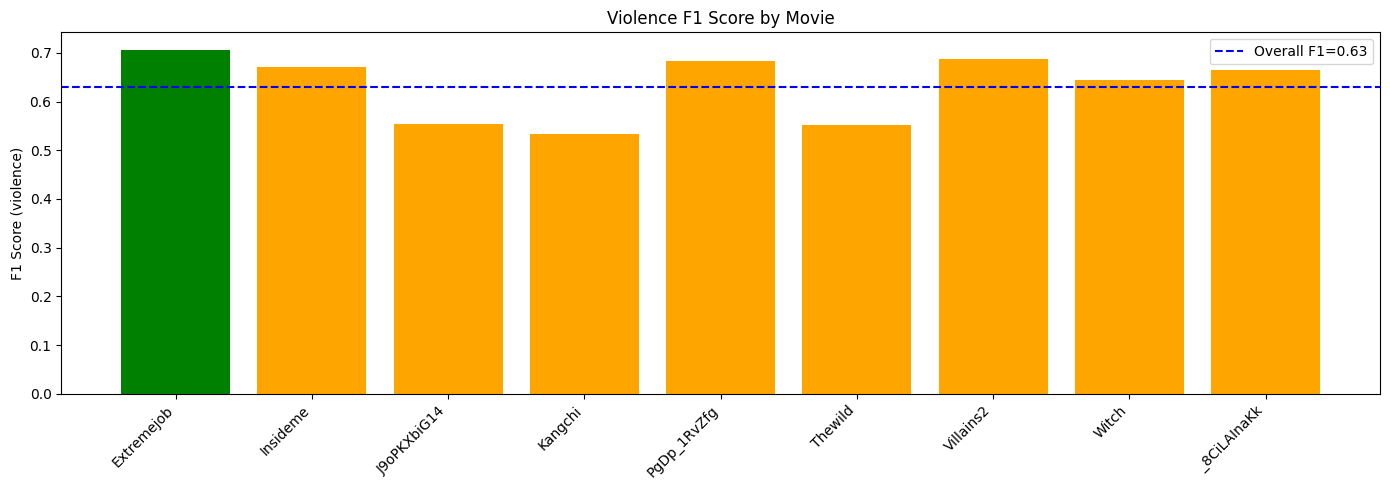

In [56]:
# 2. 영화별 F1 bar chart
plt.figure(figsize=(14, 5))
movies = list(movie_results.keys())
f1_scores = [movie_results[m]['f1'] for m in movies]
colors = ['red' if f < 0.5 else 'orange' if f < 0.7 else 'green' for f in f1_scores]

bars = plt.bar(range(len(movies)), f1_scores, color=colors)
plt.axhline(y=0.63, color='blue', linestyle='--', label='Overall F1=0.63')
plt.xticks(range(len(movies)), movies, rotation=45, ha='right')
plt.ylabel('F1 Score (violence)')
plt.title('Violence F1 Score by Movie')
plt.legend()
plt.tight_layout()
plt.show()



=== Attention Weight Visualization ===


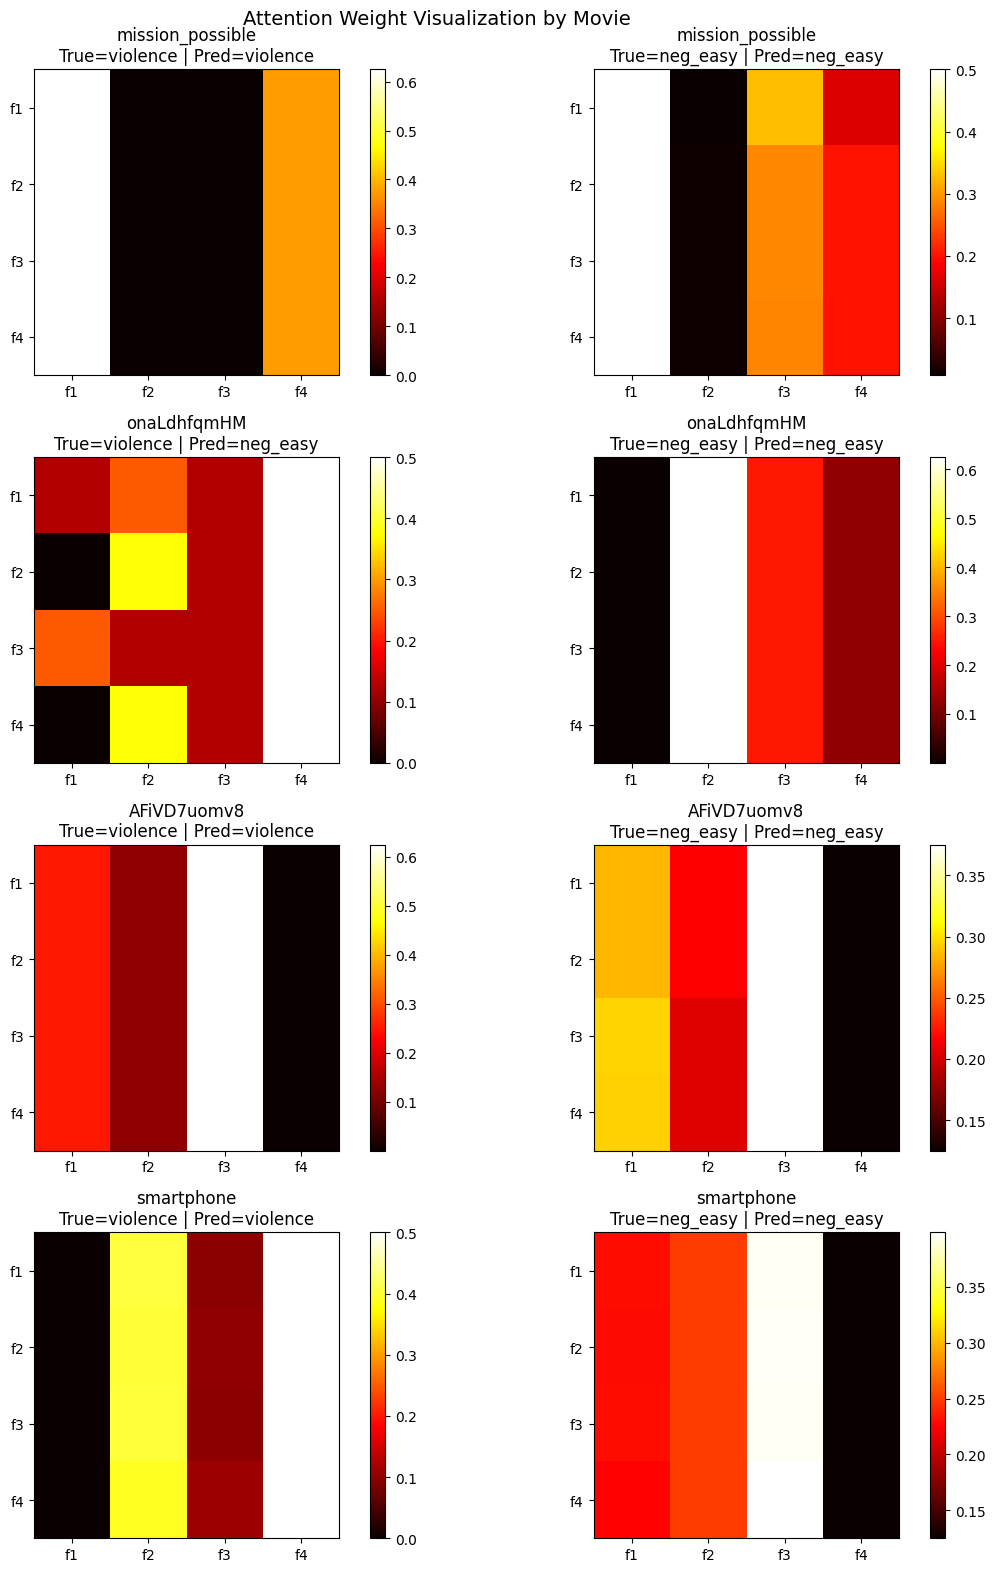

In [57]:
# 3. Attention 시각화 - 영화별로 샘플 뽑기
print('\n=== Attention Weight Visualization ===')

sample_movies = list(set(movie_ids))[:4]
fig, axes = plt.subplots(len(sample_movies), 2, figsize=(12, 4*len(sample_movies)))

for row, movie in enumerate(sample_movies):
    m_idx = np.where(movie_ids == movie)[0]
    vio_idx = m_idx[np.where(y[m_idx] == 1)[0]]
    neg_idx = m_idx[np.where(y[m_idx] == 0)[0]]

    if len(vio_idx) == 0 or len(neg_idx) == 0:
        continue

    for col, (sample_idx, label_name) in enumerate([(vio_idx[0], 'violence'), (neg_idx[0], 'neg_easy')]):
        sample = torch.tensor(X_norm[sample_idx:sample_idx+1]).to(device)
        with torch.no_grad():
            logit, attn_weights = model_viz(sample, return_attn=True)
            pred = logit.argmax(1).item()

        attn_map = attn_weights[-1][0].numpy()
        ax = axes[row][col]
        im = ax.imshow(attn_map, cmap='hot')
        ax.set_title(f'{movie}\nTrue={label_name} | Pred={"violence" if pred==1 else "neg_easy"}')
        ax.set_xticks(range(4))
        ax.set_yticks(range(4))
        ax.set_xticklabels([f'f{i+1}' for i in range(4)])
        ax.set_yticklabels([f'f{i+1}' for i in range(4)])
        plt.colorbar(im, ax=ax)

plt.suptitle('Attention Weight Visualization by Movie', fontsize=14)
plt.tight_layout()
plt.show()